In [1]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from datetime import date
# pd.set_option('display.max_columns', None)
# pl.Config.set_tbl_rows(-1)
path = "/home/jovyan/work/data/bronze/Polars/"

In [2]:
fraud_date_df = (
    pl.scan_parquet(f"{path}complete_fraud_data.parquet")
    .with_columns(
        target = pl.when(pl.col("target")).then(pl.lit("Fraudulent"))
                   .when(~pl.col("target")).then(pl.lit("Legitimate"))
                   .otherwise(pl.lit("Unlabeled")),
        day = pl.col("date").cast(pl.Date)
    )
    .select("date", "day", "target", "client_id", "use_chip", "amount")
)

Rows = fraud_date_df.select(pl.len()).collect().item()
Columns = len(fraud_date_df.collect_schema().names())
print(f"Rows: {Rows}, Columns: {Columns}")

fraud_date_df.show(5)

Rows: 13305915, Columns: 6


date,day,target,client_id,use_chip,amount
datetime[μs],date,str,str,cat,f64
2010-01-01 06:55:00,2010-01-01,"""Legitimate""","""822""","""Swipe Transaction""",10.64
2010-01-01 06:59:00,2010-01-01,"""Legitimate""","""1147""","""Swipe Transaction""",6.71
2010-01-01 08:29:00,2010-01-01,"""Legitimate""","""1541""","""Swipe Transaction""",-90.0
2010-01-01 07:21:00,2010-01-01,"""Legitimate""","""148""","""Swipe Transaction""",8.6
2010-01-01 07:11:00,2010-01-01,"""Legitimate""","""1248""","""Swipe Transaction""",72.85


In [105]:
fraud_perc_df = (
    fraud_date_df
    .group_by("target")
    .agg(
        Total = pl.len(),
        Percentage = pl.len() / Rows * 100
    )
    .collect()
)

fraud_perc_df.show()

target,Total,Percentage
str,u32,f64
"""Unlabeled""",4390952,33.0
"""Fraudulent""",13332,0.100196
"""Legitimate""",8901631,66.899804


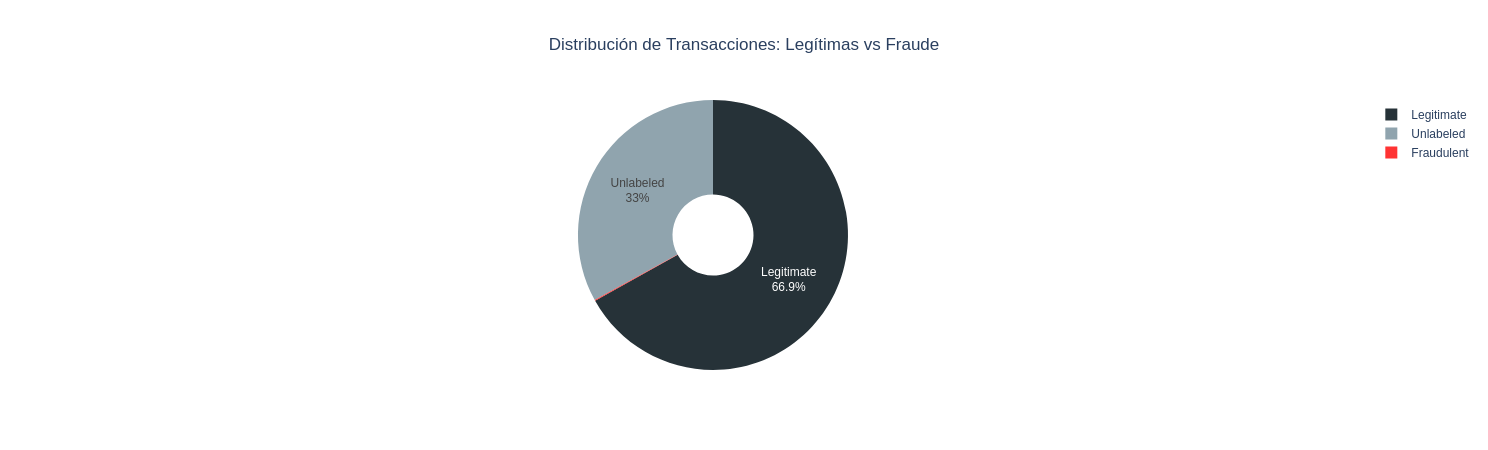

In [51]:
fraud_perc_fig = px.pie(
    fraud_perc_df ,
    values='Total', 
    names='target', 
    title= 'Distribución de Transacciones: Legítimas vs Fraude',
    color='target',
    color_discrete_map={'Legitimate': '#263238', 'Fraudulent': '#FF3333', 'Unlabeled': '#90A4AE'},
    hole=0.3
    )
fraud_perc_fig.update_traces(
    textposition='inside', 
    textinfo='percent+label',
    )
fraud_perc_fig.update_layout(width=650, height=450, title_x=0.5, autosize=False)

fraud_perc_fig.show()

In [52]:
val_min = fraud_date_df.select(pl.col("day").min()).collect().item()
val_max = fraud_date_df.select(pl.col("day").max()).collect().item()
print(F"Minimum date: {val_min}\nMaximum date: {val_max}")

Minimum date: 2010-01-01
Maximum date: 2019-10-31


In [54]:
transactions_evolution_df = (
    fraud_date_df
    .group_by("day", "target") 
    .len()
    .sort("day")
    .collect()
)
transactions_evolution_df.show(10)

day,target,len
date,str,u32
2010-01-01,"""Unlabeled""",1134
2010-01-01,"""Fraudulent""",1
2010-01-01,"""Legitimate""",2328
2010-01-02,"""Legitimate""",1971
2010-01-02,"""Unlabeled""",1018
2010-01-03,"""Fraudulent""",1
2010-01-03,"""Unlabeled""",1110
2010-01-03,"""Legitimate""",2200
2010-01-04,"""Unlabeled""",1028


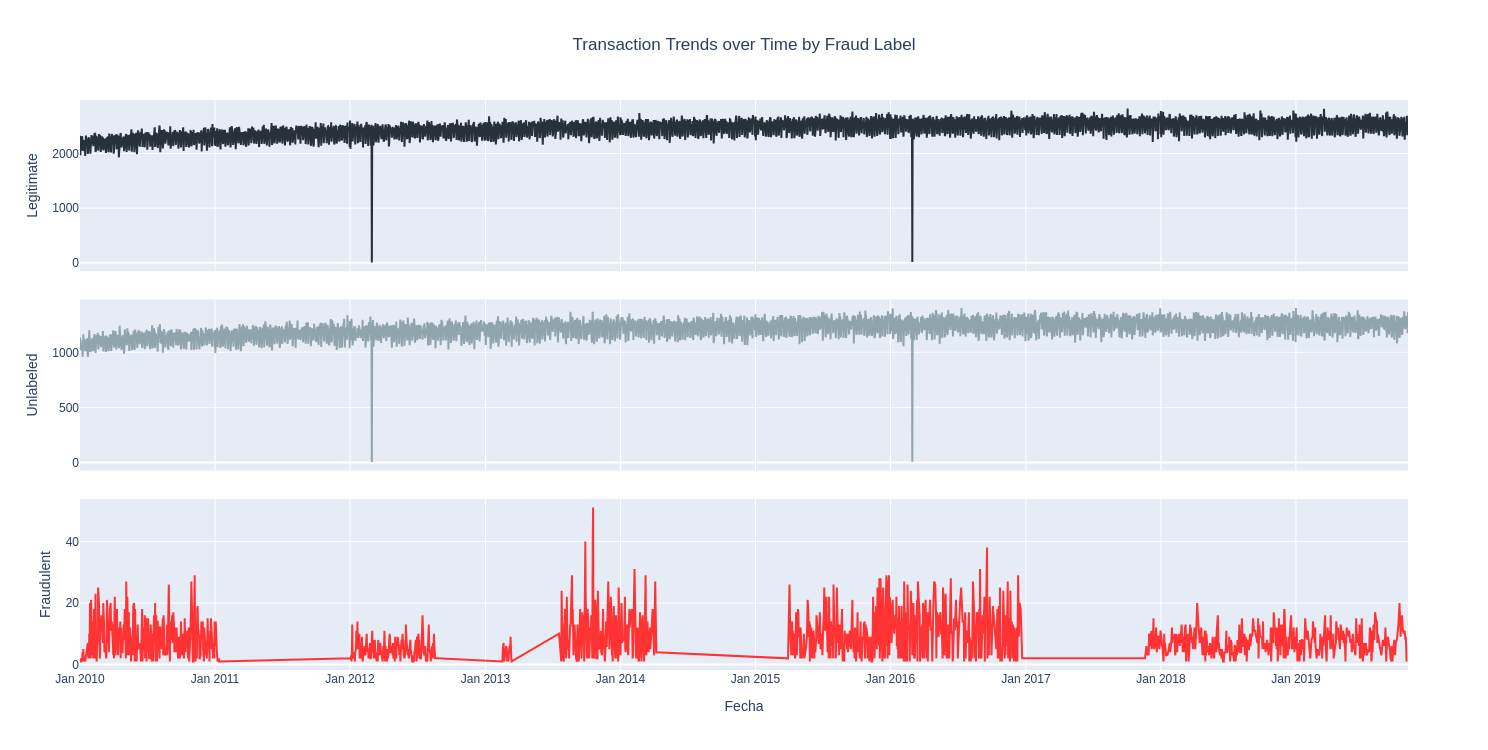

In [90]:
transactions_evolution_false = transactions_evolution_df.filter(pl.col('target') == 'Legitimate')
transactions_evolution_true = transactions_evolution_df.filter(pl.col('target') == 'Fraudulent')
transactions_evolution_null = transactions_evolution_df.filter(pl.col('target') == 'Unlabeled')

transactions_evolution_plot = go.Figure()

transactions_evolution_plot.add_trace(go.Scatter(
    x=transactions_evolution_false['day'], 
    y=transactions_evolution_false['len'], 
    name='Legitimate',
    line=dict(color='#263238', width=2),
    yaxis='y' 
))

transactions_evolution_plot.add_trace(go.Scatter(
    x=transactions_evolution_null['day'], 
    y=transactions_evolution_null['len'], 
    name='Unlabeled',
    line=dict(color='#90A4AE', width=2),
    yaxis='y2' 
))

transactions_evolution_plot.add_trace(go.Scatter(
    x=transactions_evolution_true['day'], 
    y=transactions_evolution_true['len'], 
    name='Fraudulent',
    line=dict(color='#FF3333', width=2),
    yaxis='y3' 
))

transactions_evolution_plot.update_layout(
    title_text='Transaction Trends over Time by Fraud Label', title_x=0.5, 
    width=900, height=750, autosize = False,
    hovermode='x',
    legend_title_text='', showlegend=False,
    
    yaxis=dict(
        title= dict(text='Legitimate', standoff=10),
        domain=[0.7, 1.0],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    yaxis2=dict(
        title= dict(text='Unlabeled', standoff=10), 
        domain=[0.35, 0.65], 
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),

    yaxis3=dict(
        title=dict(text='Fraudulent', standoff=10), 
        domain=[0.0, 0.30],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    xaxis=dict(
        title='Fecha',
        tickformat='%b %Y',
        hoverformat='%A, %d %b %Y',
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
        anchor='y3',      
        side='bottom' 
    )
)

transactions_evolution_plot.show()

In [3]:
date_fraud_unbiased_df = (
    fraud_date_df
    .filter(
        ((pl.col("day").is_between(date(2010, 1, 1), date(2011, 1, 8))) |
         (pl.col("day").is_between(date(2013, 7, 19), date(2014, 4, 8))) |
         (pl.col("day").is_between(date(2015, 3, 30), date(2016, 12, 22)))
        ) &
        (pl.col("day") != date(2016, 2, 29)) &
        (pl.col("target") != "Unlabeled")
    )
    .with_columns(
        hour = pl.col("date").dt.hour(),
        minute = pl.col("date").dt.minute(),
        time_str = pl.col("date").dt.to_string("%H:%M"),
    )
    .with_columns(minutes_of_day = (pl.col("hour").cast(pl.Int32) * 60) + pl.col("minute"))
    .select("target", "client_id", "day", "time_str", "minutes_of_day", "use_chip", "amount")
)

Rows_unbiased = date_fraud_unbiased_df.select(pl.len()).collect().item()
Columns_unbiased = len(date_fraud_unbiased_df.collect_schema().names())

print(f"Rows: {Rows_unbiased}, Columns: {Columns_unbiased}")
date_fraud_unbiased_df.show(5)

Rows: 3128626, Columns: 7


target,client_id,day,time_str,minutes_of_day,use_chip,amount
str,str,date,str,i32,cat,f64
"""Legitimate""","""822""",2010-01-01,"""06:55""",415,"""Swipe Transaction""",10.64
"""Legitimate""","""1147""",2010-01-01,"""06:59""",419,"""Swipe Transaction""",6.71
"""Legitimate""","""1541""",2010-01-01,"""08:29""",509,"""Swipe Transaction""",-90.0
"""Legitimate""","""148""",2010-01-01,"""07:21""",441,"""Swipe Transaction""",8.6
"""Legitimate""","""1248""",2010-01-01,"""07:11""",431,"""Swipe Transaction""",72.85


In [159]:
fraud_unbiased_perc_df = (
    date_fraud_unbiased_df
    .group_by("target")
    .agg(
        Total = pl.len(),
        Percentage = pl.len() / Rows_unbiased * 100
    )
    .collect()
)

fraud_unbiased_perc_df.show()

target,Total,Percentage
str,u32,f64
"""Legitimate""",3119448,99.706644
"""Fraudulent""",9178,0.293356


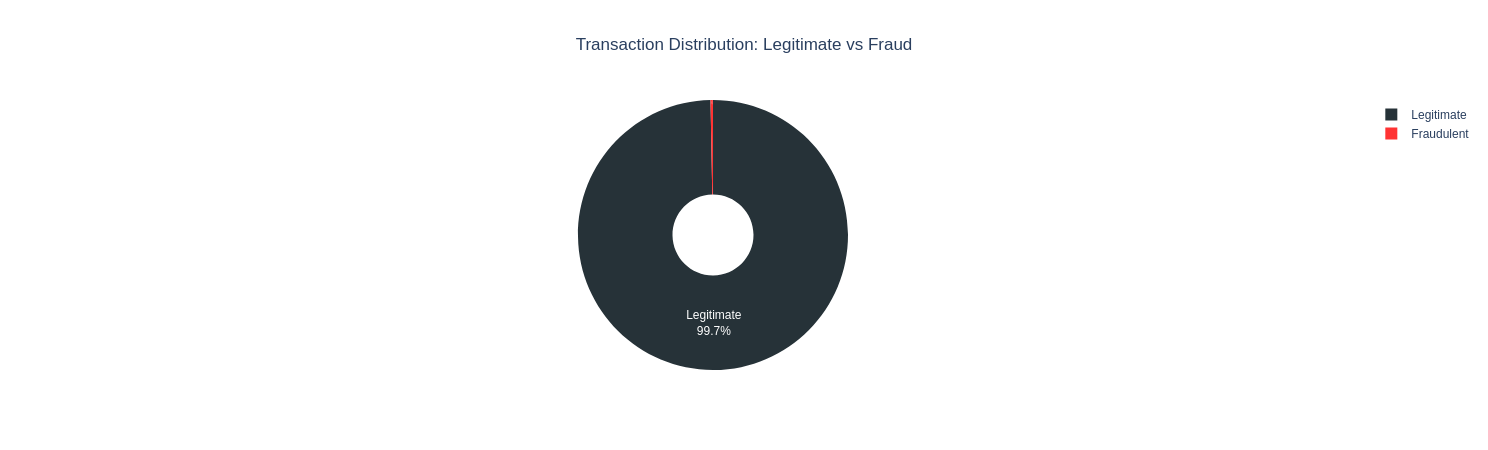

In [160]:
fraud_unbiased_perc_fig = px.pie(
    fraud_unbiased_perc_df,
    values='Total', 
    names='target', 
    title= 'Transaction Distribution: Legitimate vs Fraud',
    color='target',
    color_discrete_map={'Legitimate': '#263238', 'Fraudulent': '#FF3333'},
    hole=0.3
    )

fraud_unbiased_perc_fig.update_traces(
    textposition='inside', 
    textinfo='percent+label',
    )
fraud_unbiased_perc_fig.update_layout(width=650, height=450, title_x=0.5, autosize=False)

fraud_unbiased_perc_fig.show()

In [161]:
transactions_evolution_unbiased_df = (
    date_fraud_unbiased_df
    .group_by("day", "target") 
    .len()
    .sort("day")
    .collect()
)

transactions_evolution_unbiased_df.show(10)

day,target,len
date,str,u32
2010-01-01,"""Legitimate""",2328
2010-01-01,"""Fraudulent""",1
2010-01-02,"""Legitimate""",1971
2010-01-03,"""Legitimate""",2200
2010-01-03,"""Fraudulent""",1
2010-01-04,"""Fraudulent""",2
2010-01-04,"""Legitimate""",2214
2010-01-05,"""Fraudulent""",1
2010-01-05,"""Legitimate""",2268


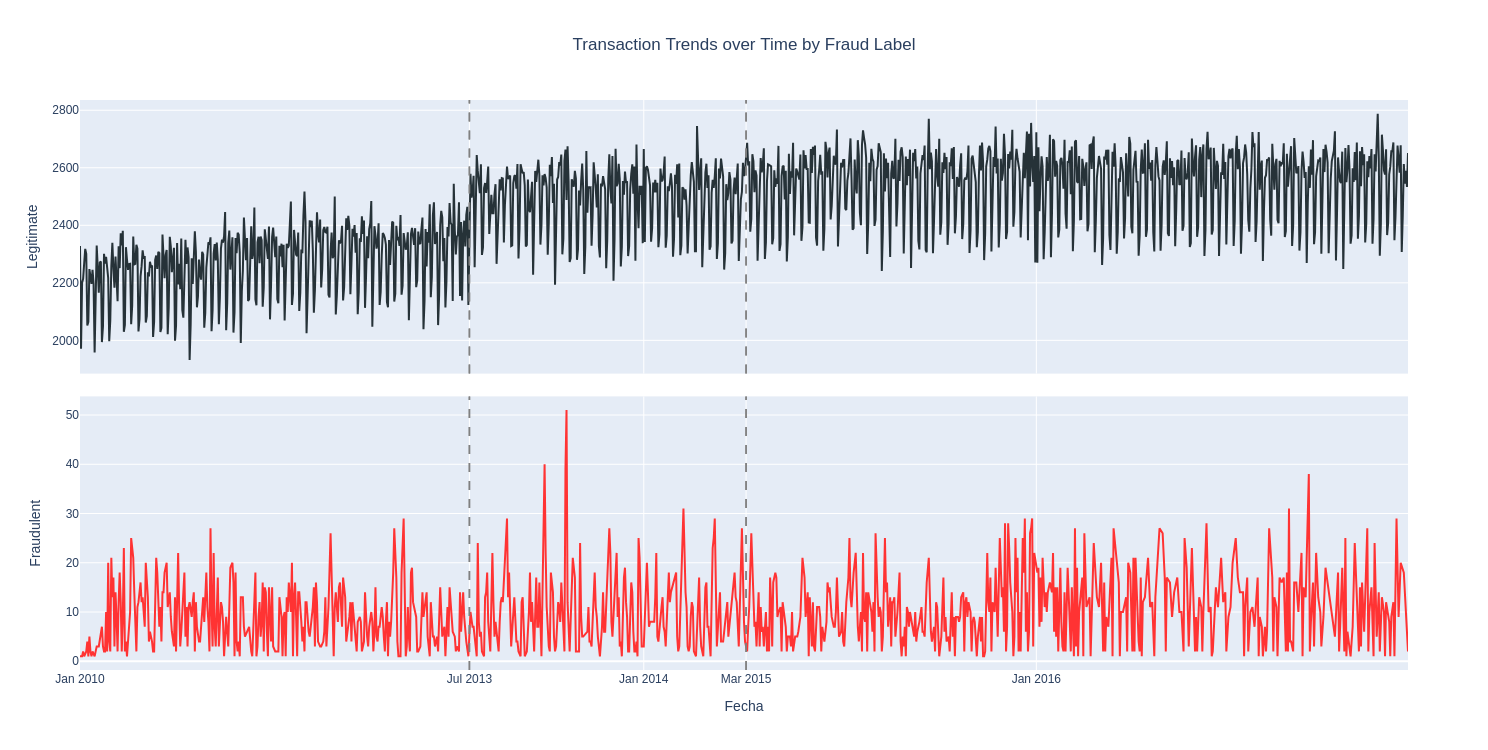

In [162]:
transactions_evolution_unbiased_false = transactions_evolution_unbiased_df.filter(pl.col('target') == 'Legitimate')
transactions_evolution_unbiased_true = transactions_evolution_unbiased_df.filter(pl.col('target') == 'Fraudulent')

transactions_evolution_unbiased_plot = go.Figure()

transactions_evolution_unbiased_plot.add_trace(go.Scatter(
    x=transactions_evolution_unbiased_false['day'], 
    y=transactions_evolution_unbiased_false['len'], 
    name='Legitimate',
    line=dict(color='#263238', width=2),
    xaxis='x',
    yaxis='y' 
))

transactions_evolution_unbiased_plot.add_trace(go.Scatter(
    x=transactions_evolution_unbiased_true['day'], 
    y=transactions_evolution_unbiased_true['len'], 
    name='Fraudulent',
    line=dict(color='#FF3333', width=2),
    xaxis='x',
    yaxis='y2' 
))

transactions_evolution_unbiased_plot.update_layout(
    title_text='Transaction Trends over Time by Fraud Label', title_x=0.5,
    width=900, height=750, autosize=False,
    hovermode='x',
    legend_title_text='', showlegend=False,
    
    yaxis=dict(
        title= dict(text='Legitimate', standoff=10),
        domain=[0.52, 1.0],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    yaxis2=dict(
        title= dict(text='Fraudulent', standoff=20),
        domain=[0.0, 0.48],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    xaxis=dict(
        title='Fecha',
        type='date', tickformat='%b %Y', hoverformat='%A, %d %b %Y',
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
        anchor='y2', side='bottom',
        rangebreaks=[
            dict(bounds=["2011-01-09", "2013-07-18"]), 
            dict(bounds=["2014-04-09", "2015-03-29"])
        ] 
    )
)

for fecha in ["2011-01-09", "2013-07-18", "2014-04-09", "2015-03-29"]:
    transactions_evolution_unbiased_plot.add_shape(
        type="line", xref="x", yref="paper",
        x0=fecha, x1=fecha, y0=0.52, y1=1.0,
        line=dict(color="gray", width=1.5, dash="dash")
)

for fecha in ["2011-01-09", "2013-07-18", "2014-04-09", "2015-03-29"]:
    transactions_evolution_unbiased_plot.add_shape(
        type="line", xref="x", yref="paper",
        x0=fecha, x1=fecha, y0=0.0, y1=0.48,
        line=dict(color="gray", width=1.5, dash="dash")
)

transactions_evolution_unbiased_plot.show()

In [164]:
monthly_unbiased_df = (
    transactions_evolution_unbiased_df
    .with_columns(
        month_num = pl.col("day").dt.month(),
        month_name= pl.col("day").dt.to_string("%B")
    )
    .group_by("month_num", "month_name", "target")
    .agg(Average_Transactions = pl.col("len").mean())
    .sort("month_num", "target")
)

monthly_unbiased_df.show(10)

month_num,month_name,target,Average_Transactions
i8,str,str,f64
1,"""January""","""Fraudulent""",8.56
1,"""January""","""Legitimate""",2406.366337
2,"""February""","""Fraudulent""",10.285714
2,"""February""","""Legitimate""",2426.916667
3,"""March""","""Fraudulent""",11.296875
3,"""March""","""Legitimate""",2427.210526
4,"""April""","""Fraudulent""",10.013514
4,"""April""","""Legitimate""",2428.316327
5,"""May""","""Fraudulent""",10.393939


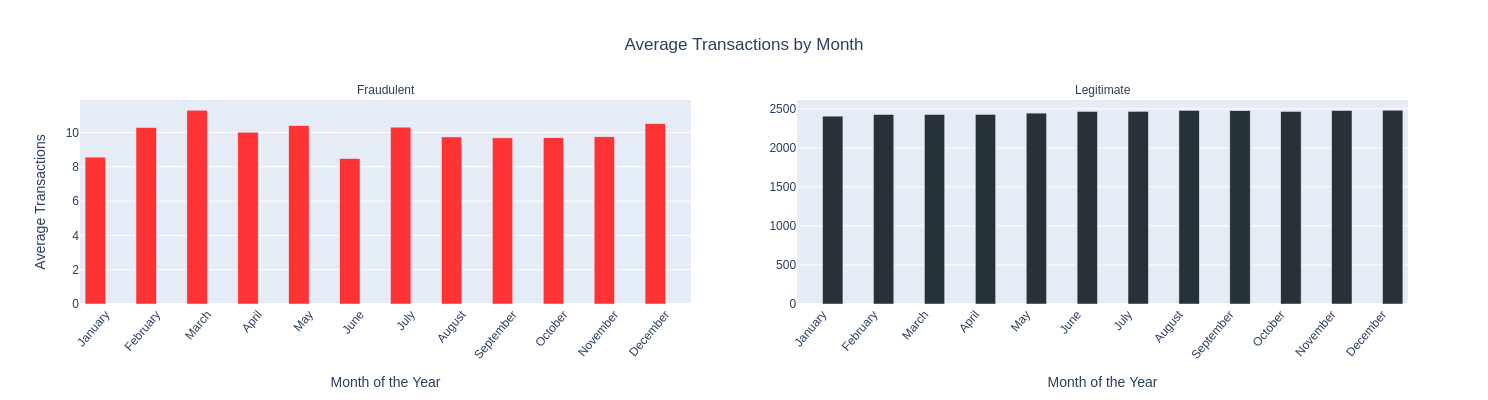

In [165]:
monthly_unbiased_plot = px.bar(
    monthly_unbiased_df,
    x="month_name",                  
    y="Average_Transactions",        
    color="target",
    facet_col="target",             
    facet_col_spacing=0.08,       
    barmode="group",
    title="Average Transactions by Month",
    labels={
        "month_name": "Month of the Year", 
        "Average_Transactions": "Average Transactions",
        "target": ""
    },
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"} 
)

monthly_unbiased_plot.update_traces(
    hovertemplate="Avg: %{y:,.2f}<extra></extra>"
)

monthly_unbiased_plot.update_yaxes(matches=None, showticklabels=True)
monthly_unbiased_plot.update_xaxes(showticklabels=True, tickangle=-50) 

monthly_unbiased_plot.update_layout(
    title_x=0.5, hovermode="closest", 
    width=900, height=400, autosize=False,
    showlegend=False
)

monthly_unbiased_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

monthly_unbiased_plot.show()


In [166]:
weekday_unbiased_df = (
    transactions_evolution_unbiased_df
    .with_columns(
        weekday_num = pl.col("day").dt.weekday(),
        weekday_name = pl.col("day").dt.to_string("%A")
    )
    .group_by("weekday_num", "weekday_name", "target")
    .agg(Avg = pl.col("len").mean())
    .sort("weekday_num")
)

weekday_unbiased_df.show(10)

weekday_num,weekday_name,target,Avg
i8,str,str,f64
1,"""Monday""","""Fraudulent""",8.506494
1,"""Monday""","""Legitimate""",2519.414365
2,"""Tuesday""","""Fraudulent""",9.207547
2,"""Tuesday""","""Legitimate""",2480.626374
3,"""Wednesday""","""Fraudulent""",5.448276
3,"""Wednesday""","""Legitimate""",2482.662983
4,"""Thursday""","""Legitimate""",2463.022099
4,"""Thursday""","""Fraudulent""",9.309524
5,"""Friday""","""Legitimate""",2326.379121


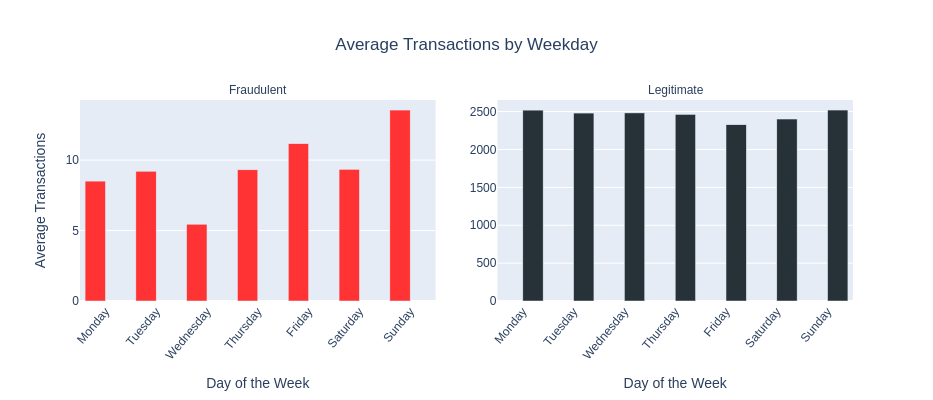

In [167]:
weekday_unbiased_plot = px.bar(
    weekday_unbiased_df,
    x="weekday_name",
    y="Avg",
    color="target",
    facet_col="target",
    facet_col_spacing=0.08,
    barmode="group",
    title="Average Transactions by Weekday",
    labels={"weekday_name": "Day of the Week", "Avg": "Average Transactions","target": ""},
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"} 
)

weekday_unbiased_plot.update_traces(
    hovertemplate="Avg: %{y:,.2f}<extra></extra>"
)

weekday_unbiased_plot.update_yaxes(matches=None, showticklabels=True)
weekday_unbiased_plot.update_xaxes(showticklabels=True, tickangle=-50) 

weekday_unbiased_plot.update_layout(
    title_x=0.5,
    width=900, height=400, autosize=False,
    hovermode="closest",
    showlegend=False
)

weekday_unbiased_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

weekday_unbiased_plot.show()


In [168]:
monthday_unbiased_df = (
    transactions_evolution_unbiased_df
    .with_columns(day_of_month = pl.col("day").dt.day())
    .group_by("day_of_month", "target")
    .agg(Average_Transactions = pl.col("len").mean())
    .sort("day_of_month")
)

monthday_unbiased_df.show(10)

day_of_month,target,Average_Transactions
i8,str,f64
1,"""Fraudulent""",8.764706
1,"""Legitimate""",2486.069767
2,"""Legitimate""",2440.093023
2,"""Fraudulent""",8.870968
3,"""Fraudulent""",8.515152
3,"""Legitimate""",2434.27907
4,"""Legitimate""",2463.511628
4,"""Fraudulent""",9.689655
5,"""Fraudulent""",10.575758


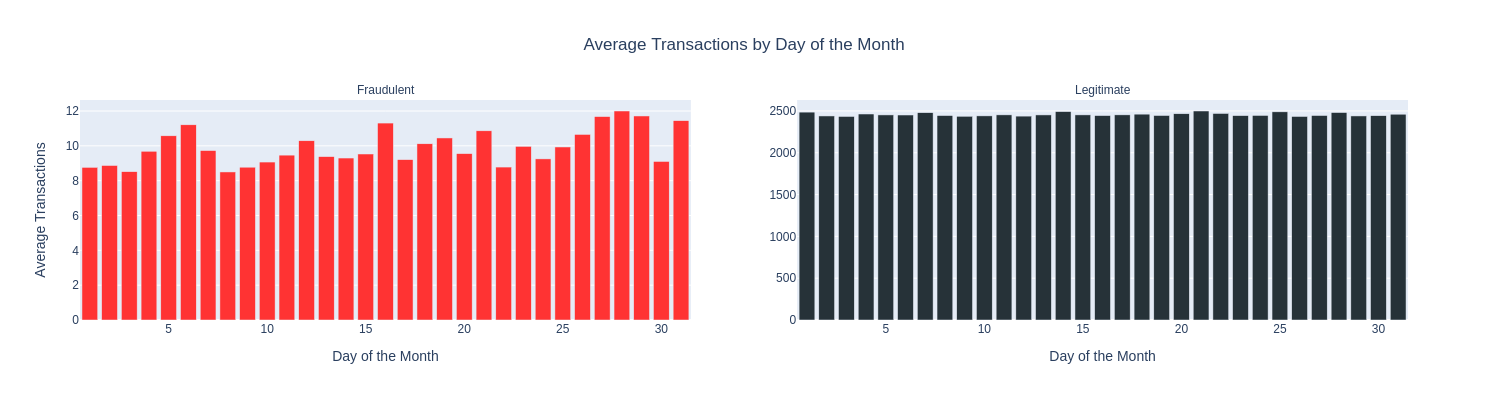

In [169]:
month_day_plot = px.bar(
    monthday_unbiased_df,
    x="day_of_month",
    y="Average_Transactions",
    color="target",
    facet_col="target",      
    facet_col_spacing=0.08,  
    title="Average Transactions by Day of the Month",
    labels={
        "day_of_month": "Day of the Month", 
        "Average_Transactions": "Average Transactions", 
        "target": ""
    },
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"}
)

month_day_plot.update_traces(
    hovertemplate="Average: %{y:,.2f}<extra></extra>"
)

month_day_plot.update_yaxes(matches=None, showticklabels=True)
month_day_plot.update_xaxes(showticklabels=True)

month_day_plot.update_layout(
    title_x=0.5,
    width=900, height=400, autosize=False,
    hovermode="x unified",
    showlegend=False

)

month_day_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

month_day_plot.show()


In [170]:
detailed_calendar_unbiased_df = (
    transactions_evolution_unbiased_df
    .with_columns(
        day_of_month = pl.col("day").dt.day(),
        weekday_num = pl.col("day").dt.weekday(),
        weekday_name = pl.col("day").dt.to_string("%A")
    )
    .group_by("day_of_month", "weekday_num", "weekday_name", "target")
    .agg(Avg = pl.col("len").mean())
    .sort("day_of_month", "weekday_num", "target")
)

Rows_cal = detailed_calendar_unbiased_df.height
Columns_cal = detailed_calendar_unbiased_df.width
print(f"Rows: {Rows_cal}, Columns: {Columns_cal}")
detailed_calendar_unbiased_df.show(20)


Rows: 434, Columns: 5


day_of_month,weekday_num,weekday_name,target,Avg
i8,i8,str,str,f64
1,1,"""Monday""","""Fraudulent""",8.4
1,1,"""Monday""","""Legitimate""",2493.166667
1,2,"""Tuesday""","""Fraudulent""",9.333333
1,2,"""Tuesday""","""Legitimate""",2553.285714
1,3,"""Wednesday""","""Fraudulent""",4.0
1,3,"""Wednesday""","""Legitimate""",2531.5
1,4,"""Thursday""","""Fraudulent""",7.0
1,4,"""Thursday""","""Legitimate""",2492.166667
1,5,"""Friday""","""Fraudulent""",10.4


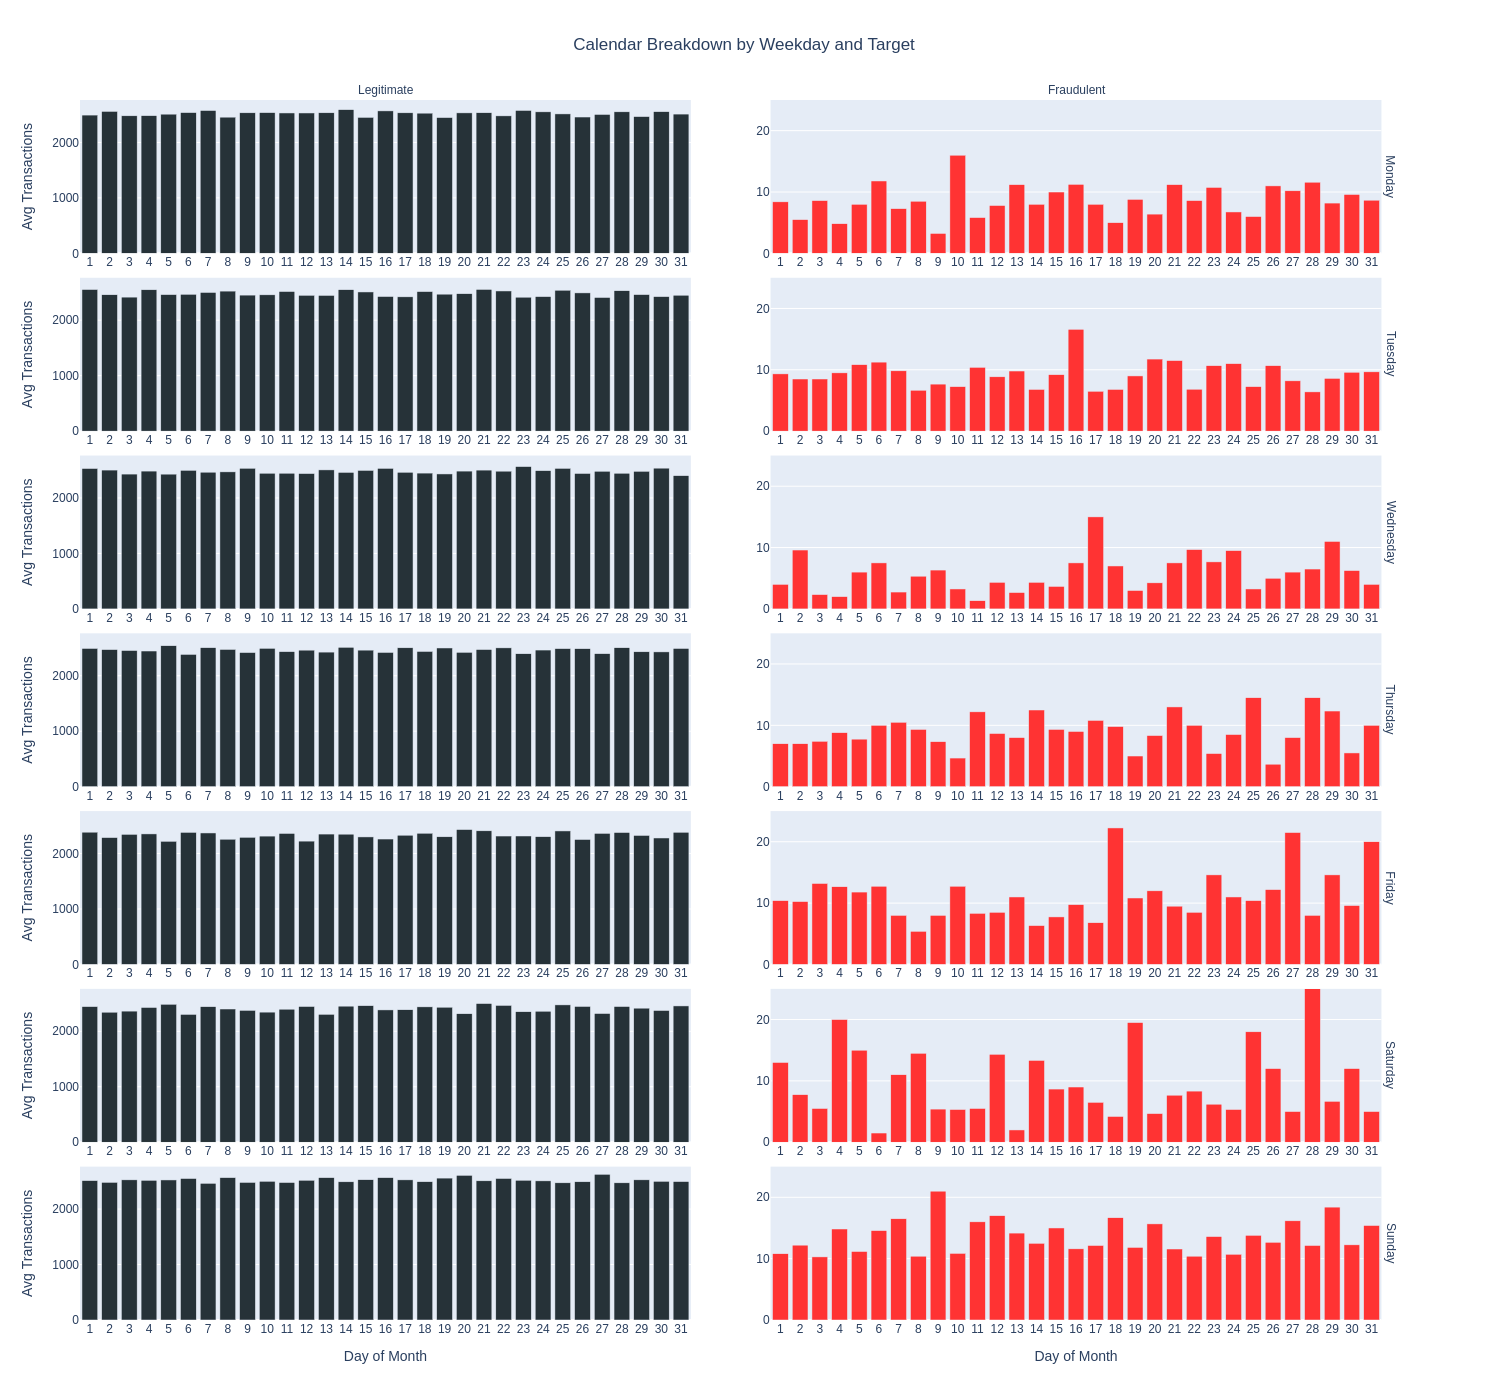

In [171]:
detailed_calendar_unbiased_df = detailed_calendar_unbiased_df.with_columns(
    pl.col("day_of_month").cast(pl.String)
)

fig_calendar = px.bar(
    detailed_calendar_unbiased_df,
    x="day_of_month",          
    y="Avg",
    color="target",
    facet_col="target",         
    facet_row="weekday_name",   
    facet_row_spacing=0.02,
    facet_col_spacing=0.06,     
    title="Calendar Breakdown by Weekday and Target",
    labels={"day_of_month": "Day of Month", "Avg": "Avg Transactions", "target": "Is Fraud?"},
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"},
    category_orders={"target": ["Legitimate", "Fraudulent"]}
)

fig_calendar.update_yaxes(matches="y", showticklabels=True, col=1)
fig_calendar.update_yaxes(matches="y2", showticklabels=True, col=2, range=[0.0, 25])

fig_calendar.update_xaxes(showticklabels=True) 

fig_calendar.update_traces(hovertemplate="Day:%{x}<br>Avg: %{y:,.2f}<extra></extra>")

fig_calendar.update_layout(
    title_x=0.5, 
    width=900, height=1400, autosize=False,
    hovermode="closest", showlegend=False
)

fig_calendar.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

fig_calendar.show()

In [176]:
time_fraud_unbiased_df = (
    date_fraud_unbiased_df
    .group_by("minutes_of_day", "time_str", "target")
    .len()
    .sort("minutes_of_day")
    .collect()
)

time_fraud_unbiased_df.show(10)

minutes_of_day,time_str,target,len
i32,str,str,u32
0,"""00:00""","""Legitimate""",551
1,"""00:01""","""Fraudulent""",1
1,"""00:01""","""Legitimate""",510
2,"""00:02""","""Legitimate""",510
3,"""00:03""","""Legitimate""",482
4,"""00:04""","""Legitimate""",486
5,"""00:05""","""Legitimate""",506
6,"""00:06""","""Legitimate""",510
7,"""00:07""","""Legitimate""",495


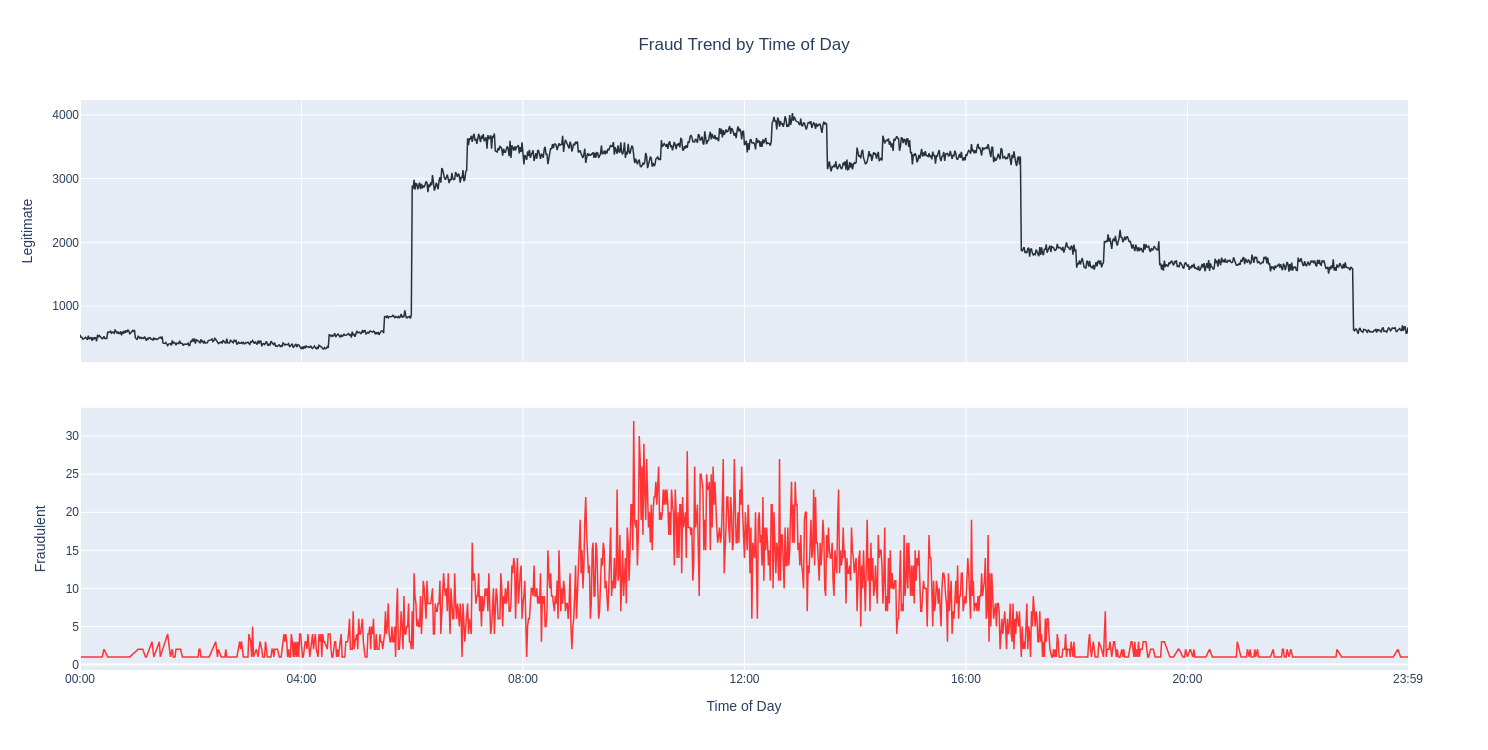

In [243]:
time_fraud_false = time_fraud_unbiased_df.filter(pl.col('target') == 'Legitimate')
time_fraud_true = time_fraud_unbiased_df.filter(pl.col('target') == 'Fraudulent')

time_evolution_plot = go.Figure()

time_evolution_plot.add_trace(go.Scatter(
    x=time_fraud_false['minutes_of_day'],
    y=time_fraud_false['len'], 
    name='Legitimate',
    mode='lines',
    line=dict(color='#263238', width=1.5),
    xaxis='x', yaxis='y',
    customdata=time_fraud_false['time_str'],
    hovertemplate="Time: %{customdata}<br>Count: %{y:,.0f}<extra></extra>"
))

time_evolution_plot.add_trace(go.Scatter(
    x=time_fraud_true['minutes_of_day'],
    y=time_fraud_true['len'], 
    name='Fraudulent',
    mode='lines',
    line=dict(color='#FF3333', width=1.5),
    xaxis='x', yaxis='y2',
    customdata=time_fraud_true['time_str'],
    hovertemplate="Time: %{customdata}<br>Count: %{y:,.0f}<extra></extra>"
))

time_evolution_plot.update_layout(
    title_text='Fraud Trend by Time of Day',
    title_x=0.5,
    width=900, height=750,
    hovermode='closest',
    showlegend=False,
    
    yaxis=dict(
        title=dict(text='Legitimate'), 
        domain=[0.54, 1.0], 
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"),
    yaxis2=dict(
        title=dict(text='Fraudulent'), 
        domain=[0.0, 0.46],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"),
    
    xaxis=dict(
        title='Time of Day',
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
        anchor='y2', side='bottom',
        tickmode="array",
        tickvals=[0, 240, 480, 720, 960, 1200, 1439],
        ticktext=["00:00", "04:00", "08:00", "12:00", "16:00", "20:00", "23:59"]
    )
)

time_evolution_plot.show()

In [179]:
date_fraud_unbiased_df.show(10)

target,client_id,day,time_str,minutes_of_day,use_chip,amount
str,str,date,str,i32,cat,f64
"""Legitimate""","""822""",2010-01-01,"""06:55""",415,"""Swipe Transaction""",10.64
"""Legitimate""","""1147""",2010-01-01,"""06:59""",419,"""Swipe Transaction""",6.71
"""Legitimate""","""1541""",2010-01-01,"""08:29""",509,"""Swipe Transaction""",-90.0
"""Legitimate""","""148""",2010-01-01,"""07:21""",441,"""Swipe Transaction""",8.6
"""Legitimate""","""1248""",2010-01-01,"""07:11""",431,"""Swipe Transaction""",72.85
"""Legitimate""","""754""",2010-01-01,"""06:23""",383,"""Swipe Transaction""",39.07
"""Legitimate""","""319""",2010-01-01,"""03:17""",197,"""Swipe Transaction""",29.6
"""Legitimate""","""354""",2010-01-01,"""07:09""",429,"""Swipe Transaction""",5.76
"""Legitimate""","""1313""",2010-01-01,"""02:57""",177,"""Swipe Transaction""",2.77


In [4]:
fraudulent_client_df = (
    date_fraud_unbiased_df
    .select("client_id", "target")
    .filter(pl.col("target") == 'Fraudulent')
    .unique()
    .collect()
)

fraudulent_client_list = fraudulent_client_df["client_id"].to_list()
print("Total Clients with Fraudulent Transactions:", len(fraudulent_client_list))

Total Clients with Fraudulent Transactions: 1045


In [9]:
client_df = (
    date_fraud_unbiased_df
    .filter(pl.col("client_id").is_in(fraudulent_client_list))
    .select("client_id", "day", "time_str", "minutes_of_day", "use_chip", "target", "amount")
)

Rows_client = client_df.select(pl.len()).collect().item()
Columns_client = len(client_df.collect_schema().names())

print(f"Rows: {Rows_client}, Columns: {Columns_client}")
client_df.show(5)

Rows: 2728092, Columns: 7


client_id,day,time_str,minutes_of_day,use_chip,target,amount
str,date,str,i32,cat,str,f64
"""822""",2010-01-01,"""06:55""",415,"""Swipe Transaction""","""Legitimate""",10.64
"""1147""",2010-01-01,"""06:59""",419,"""Swipe Transaction""","""Legitimate""",6.71
"""1541""",2010-01-01,"""08:29""",509,"""Swipe Transaction""","""Legitimate""",-90.0
"""148""",2010-01-01,"""07:21""",441,"""Swipe Transaction""","""Legitimate""",8.6
"""1248""",2010-01-01,"""07:11""",431,"""Swipe Transaction""","""Legitimate""",72.85


In [11]:
def plot_client_behaviour_time(client_ID):
    client_transaction_df = (
        client_df
        .filter(pl.col("client_id") == client_ID)
        .sort("day")
        .with_columns(
            hover_date_str = pl.col("day").dt.to_string("%A, %d %b %Y"),
            amount_absolute = pl.col("amount").abs(),
            amount_sign = pl.when(pl.col("amount") >= 0).then(pl.lit("Positive")).otherwise(pl.lit("Negative")),
            day_str = pl.col("day").dt.to_string("%Y-%m-%d")
        )
        .collect() 
    )
    
    ordered_days = client_transaction_df["day_str"].unique(maintain_order=True).to_list()
    
    client_transaction_fig = px.scatter(
        client_transaction_df,
        x="day_str",        
        y="minutes_of_day",
        size="amount_absolute",
        symbol="amount_sign",     
        symbol_sequence=['circle', 'x'],
        color="target",
        facet_row="use_chip",         
        facet_row_spacing=0.08,       
        height=750, width=850,                
        opacity=0.6,
        category_orders={"target": ["Legitimate", "Fraudulent"]},
        custom_data=["hover_date_str", "use_chip", "time_str", "amount"],
        title= f"<b>Transactions Behaviour, ClientID: {client_ID}</b>",
        labels={"day_str": "Date", "minutes_of_day": "Time"}
    )
    
    client_transaction_fig.update_traces(
        marker=dict(line=dict(color='black', width=0.45)),
        hovertemplate="<b>%{customdata[0]}</b><br>Chip: %{customdata[1]}\
        <br>time: %{customdata[2]}<br>amount: %{customdata[3]}<extra></extra>"
    )
    
    client_transaction_fig.update_layout(
        plot_bgcolor="#F5F5F5", paper_bgcolor="white", 
        width=900, height=900, autosize=False,
        legend=dict(title="", orientation="h", yanchor="top", y=1.05, xanchor="left", x=0.1)
    )
    
    client_transaction_fig.update_xaxes(
        showticklabels=True, tickformat="%A, %d %b %Y", matches="x", tickangle=-45, nticks=12,
        type='category', categoryorder='array', categoryarray=ordered_days,
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
    
    ) 
    
    client_transaction_fig.update_xaxes(showticklabels=False, row=2)
    client_transaction_fig.update_xaxes(showticklabels=False, row=3)
    
    client_transaction_fig.update_yaxes(
        showgrid=True, gridcolor="#EAEAEA",
        tickvals=[0, 240, 480, 720, 960, 1200, 1439],
        ticktext=["00:00", "04:00", "08:00", "12:00", "16:00", "20:00", "23:59"]
    )
    
    client_transaction_fig.for_each_annotation(lambda a: a.update(
        text=f"<b>{a.text.split('=')[-1]}</b>",
        font=dict(size=14, color="black")
        )
    )
    
    client_transaction_fig.add_vline(x="2011-01-08", line_width=1.5, line_dash="dash")
    client_transaction_fig.add_vline(x="2015-03-30", line_width=1.5, line_dash="dash")
                
    return client_transaction_fig

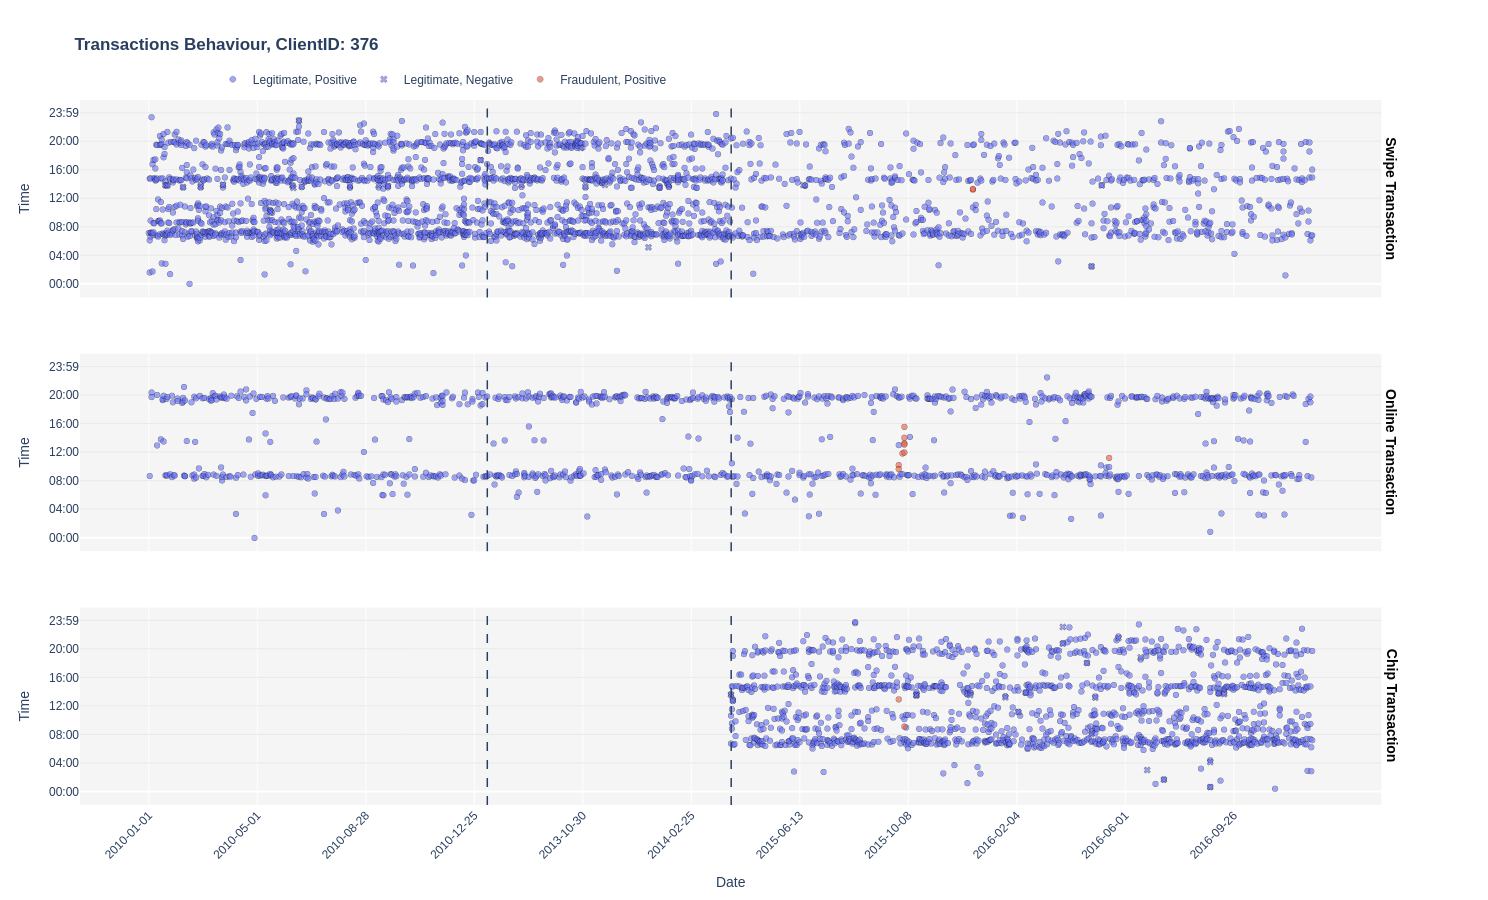

In [7]:
plot_client_behaviour_time("376")

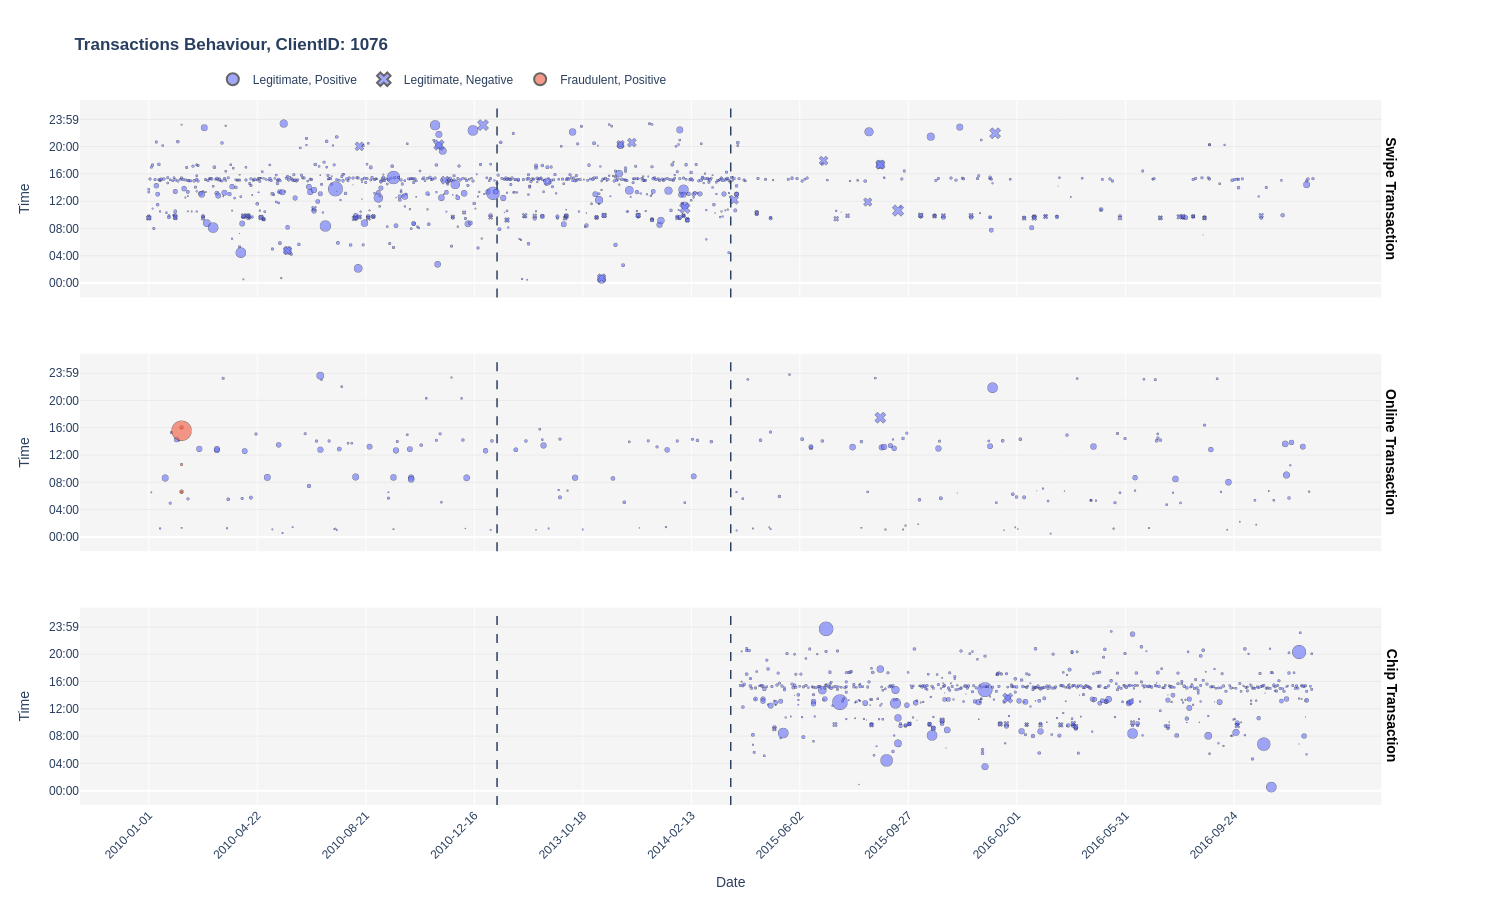

In [269]:
plot_client_behaviour_time(fraudulent_client_list[1])

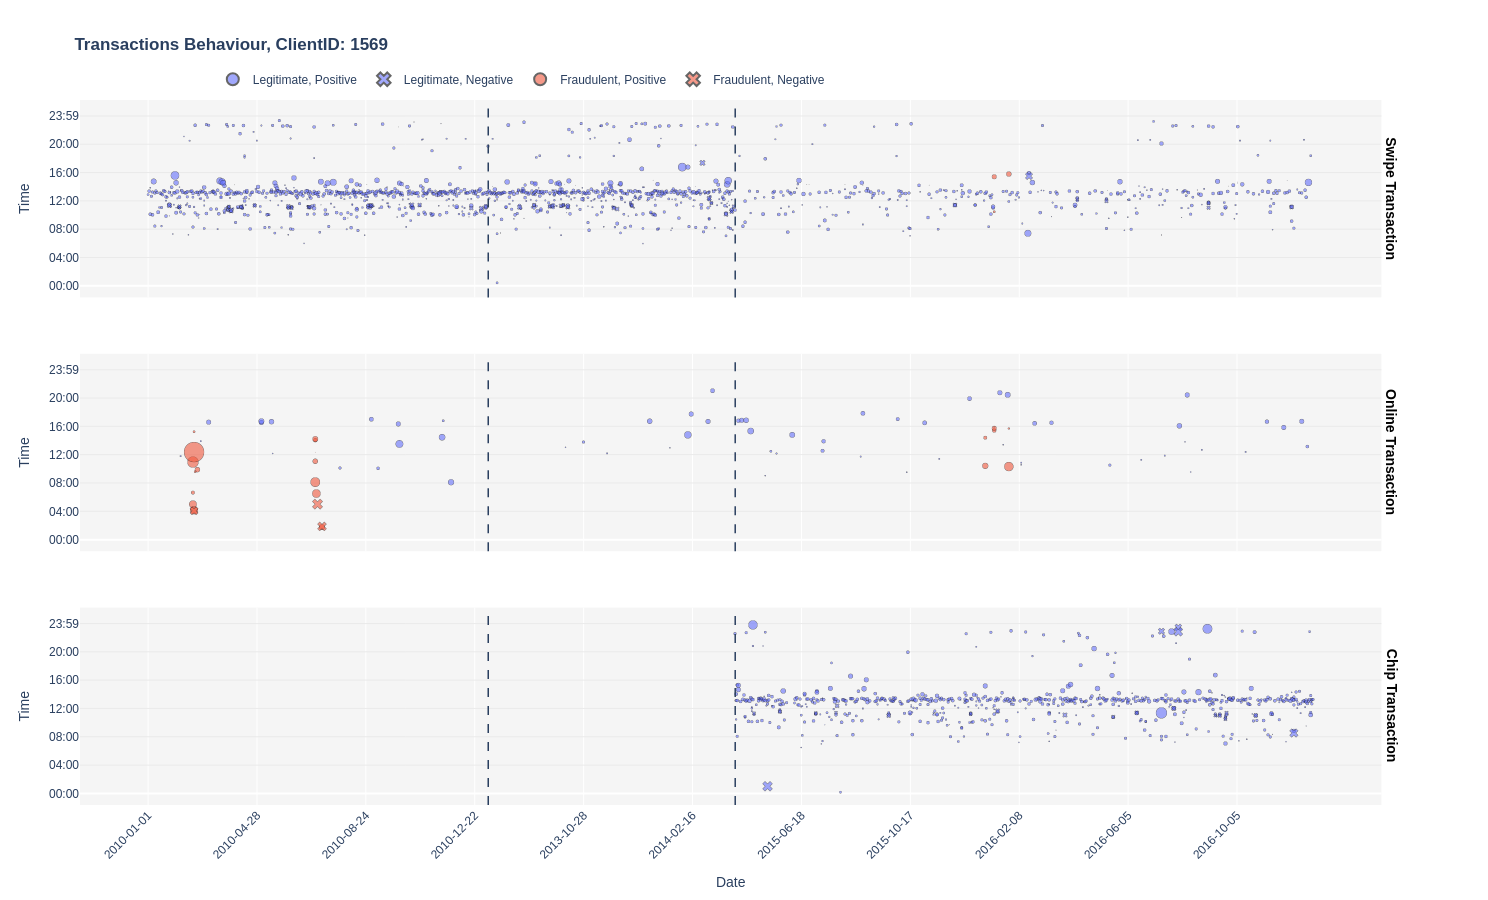

In [271]:
plot_client_behaviour_time(fraudulent_client_list[2])